# Week 4 - EDA on features.csv

Doing all 7 tasks + challenge task on the feature engineered dataset.

## Setup

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/processed/features.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 58)


,event_id,user_id,event_type,timestamp,hour_of_day,day_of_week,is_weekend,is_anomalous,anomaly_type,ip_address,...,unique_ips_last_10_logins,unique_countries_last_10_logins,unique_devices_last_10_logins,rolling_failed_attempts_5,roll_5_deposit_sum,withdrawal_to_deposit_ratio,trade_vol_zscore,pnl_zscore,amount_zscore,session_duration_zscore
0,EVT_304595,USER_0000,trade,2024-01-01 01:04:36,1,0,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.565431,-0.423405,0.000000,0.0
1,EVT_637273,USER_0000,trade,2024-01-01 16:01:51,16,0,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.582884,-0.484037,0.000000,0.0
2,EVT_749975,USER_0000,trade,2024-01-02 14:09:59,14,1,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.531557,-0.562527,0.000000,0.0
3,EVT_969821,USER_0000,login,2024-01-03 04:47:38,4,2,0,1,wash_trader,172.16.4.1,...,1.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
4,EVT_299345,USER_0000,withdrawal,2024-01-04 08:32:44,8,3,0,1,wash_trader,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,-1.180471,0.0


## Task 1: Event Distribution

Questions:
- Which event types occur most frequently?
- Are some event types rare?
- Is the dataset balanced?

In [66]:
df["event_type"].value_counts()

event_type
trade         17446
login         11014
deposit        7565
session        6021
withdrawal     5115
kyc_change     2839
Name: count, dtype: int64

<Axes: xlabel='event_type', ylabel='count'>

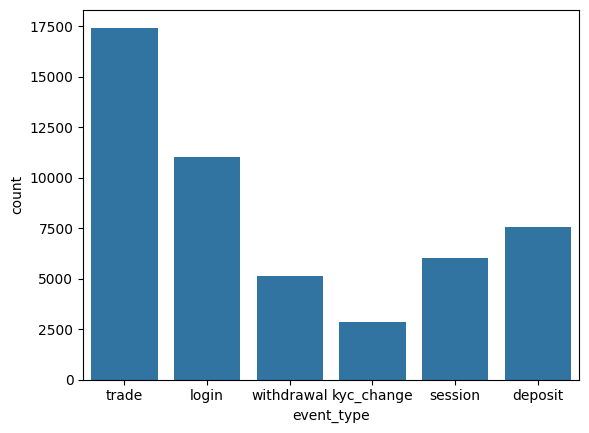

In [67]:
sns.countplot(x="event_type", data=df)

### Observations

* Trade events are the most frequent, indicating that trading is the primary platform activity.
* KYC changes are the least frequent, as users rarely update verification details.
* The dataset is imbalanced, with trades and logins occurring much more often than other event types.
* This distribution reflects realistic user behavior on a trading platform and should be considered during anomaly detection.


## Task 2: Temporal Behavior

Analyzing `time_since_last_event_sec` and `time_since_last_login_sec`

In [68]:
print(df["time_since_last_event_sec"].describe())
print()
print(df["time_since_last_login_sec"].describe())

count     50000.000000
mean      76218.170280
std       77610.041484
min           0.000000
25%       20990.000000
50%       52258.000000
75%      106098.000000
max      812325.000000
Name: time_since_last_event_sec, dtype: float64

count    5.000000e+04
mean     3.239242e+05
std      3.382257e+05
min      0.000000e+00
25%      8.032150e+04
50%      2.167855e+05
75%      4.560250e+05
max      3.284136e+06
Name: time_since_last_login_sec, dtype: float64


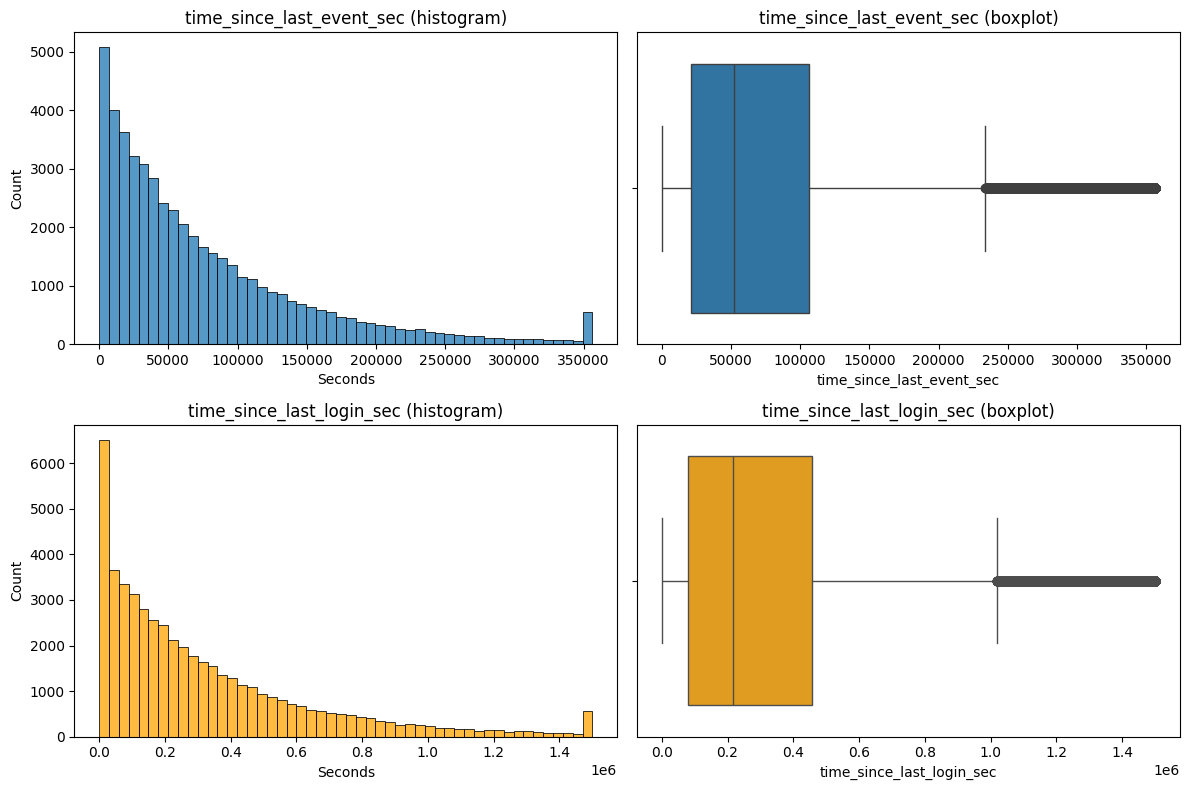

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# clip at 99th percentile so we can actually see the distribution
clip_event = df["time_since_last_event_sec"].quantile(0.99)
clip_login = df["time_since_last_login_sec"].quantile(0.99)

sns.histplot(df["time_since_last_event_sec"].clip(upper=clip_event), bins=50, ax=axes[0][0])
axes[0][0].set_title("time_since_last_event_sec (histogram)")
axes[0][0].set_xlabel("Seconds")

sns.boxplot(x=df["time_since_last_event_sec"].clip(upper=clip_event), ax=axes[0][1])
axes[0][1].set_title("time_since_last_event_sec (boxplot)")

sns.histplot(df["time_since_last_login_sec"].clip(upper=clip_login), bins=50, ax=axes[1][0], color="orange")
axes[1][0].set_title("time_since_last_login_sec (histogram)")
axes[1][0].set_xlabel("Seconds")

sns.boxplot(x=df["time_since_last_login_sec"].clip(upper=clip_login), ax=axes[1][1], color="orange")
axes[1][1].set_title("time_since_last_login_sec (boxplot)")

plt.tight_layout()
plt.show()

### Observations

* Both `time_since_last_event_sec` and `time_since_last_login_sec` are heavily right-skewed, indicating that most events and logins occur after relatively short time intervals, while a few have much longer gaps.
* The median time between consecutive events is **52,258 seconds (~14.5 hours)**, whereas the median time between consecutive logins is **216,786 seconds (~2.5 days)**, showing that users perform multiple activities between login sessions.
* The boxplots reveal numerous outliers for both features, indicating that a small number of users remain inactive for significantly longer periods than the majority.
* The maximum gap between consecutive events is **812,325 seconds (~9.4 days)**, while the maximum gap between logins reaches **3,284,136 seconds (~38 days)**, highlighting the presence of extended inactivity periods in the dataset.
* Overall, the temporal features capture both regular user activity and infrequent long inactivity periods, making them useful for identifying unusual behavioral patterns.


## Task 3: Burst Activity

Analyzing `burst_count_5min` and `burst_count_30min`

In [71]:
print("burst_count_5min value counts:")
print(df["burst_count_5min"].value_counts().sort_index())
print()
print("burst_count_30min value counts:")
print(df["burst_count_30min"].value_counts().sort_index().head(10))

burst_count_5min value counts:
burst_count_5min
1    49702
2      234
3       49
4        6
5        6
6        3
Name: count, dtype: int64

burst_count_30min value counts:
burst_count_30min
1     48703
2      1183
3        27
4        15
5        15
6        15
7        20
8        11
9         6
10        5
Name: count, dtype: int64


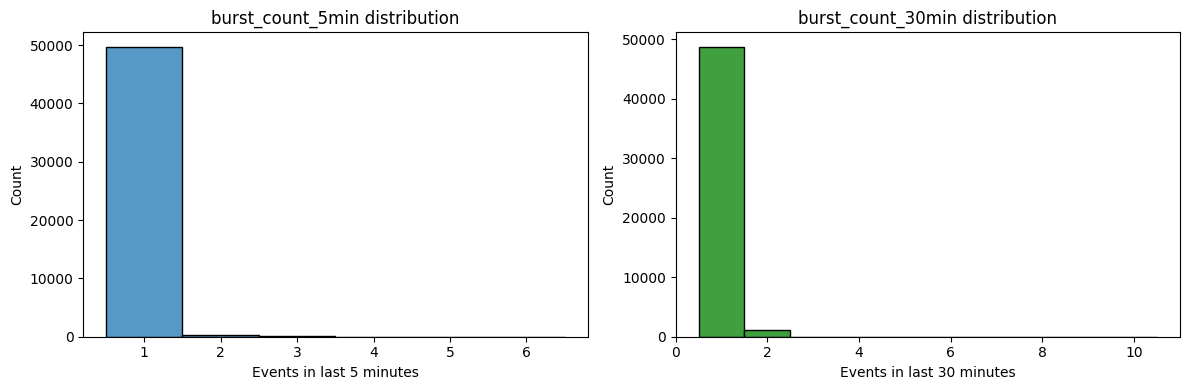

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["burst_count_5min"], bins=6, ax=axes[0], discrete=True)
axes[0].set_title("burst_count_5min distribution")
axes[0].set_xlabel("Events in last 5 minutes")

sns.histplot(df["burst_count_30min"], bins=15, ax=axes[1], discrete=True, color="green")
axes[1].set_title("burst_count_30min distribution")
axes[1].set_xlabel("Events in last 30 minutes")

plt.tight_layout()
plt.show()

In [73]:
# which users have highest burst activity
print("Users with burst_count_5min > 3:")
high_burst = df[df["burst_count_5min"] > 3][["user_id", "anomaly_type", "burst_count_5min", "timestamp"]]
print(high_burst)

Users with burst_count_5min > 3:
        user_id  anomaly_type  burst_count_5min            timestamp
531   USER_0004  brute_forcer                 4  2024-03-13 15:59:09
532   USER_0004  brute_forcer                 5  2024-03-13 15:59:39
533   USER_0004  brute_forcer                 6  2024-03-13 16:00:39
978   USER_0008  brute_forcer                 4  2024-03-29 11:35:29
979   USER_0008  brute_forcer                 5  2024-03-29 11:35:59
980   USER_0008  brute_forcer                 6  2024-03-29 11:36:59
1011  USER_0009  brute_forcer                 4  2024-01-25 11:00:47
1012  USER_0009  brute_forcer                 5  2024-01-25 11:01:17
1013  USER_0009  brute_forcer                 6  2024-01-25 11:02:17
1208  USER_0011     ip_hopper                 4  2024-01-18 14:43:41
1209  USER_0011     ip_hopper                 5  2024-01-18 14:43:41
1210  USER_0011     ip_hopper                 4  2024-01-18 14:46:41
1211  USER_0011     ip_hopper                 5  2024-01-18 14:46:41
2

**Observations:**
- Normal burst count (5min) is 1 for almost everyone - 49,702 out of 50,000 events
- Only 61 events have burst_count_5min > 1, and only 12 have it > 3
- Max burst in 5 min is 6 - definitely suspicious
- All users with burst_count_5min > 3 are either brute_forcer or ip_hopper -brute forcers fire rapid login attempts, while ip_hoppers log in from multiple IPs almost simultaneously

## Task 4: Login Behavior

Analyzing `unique_ips_last_10_logins`, `unique_countries_last_10_logins`, `unique_devices_last_10_logins`

In [74]:
print("unique_ips_last_10_logins:")
print(df["unique_ips_last_10_logins"].describe())
print()
print("unique_countries_last_10_logins:")
print(df["unique_countries_last_10_logins"].describe())
print()
print("unique_devices_last_10_logins:")
print(df["unique_devices_last_10_logins"].describe())

unique_ips_last_10_logins:
count    50000.000000
mean         0.225640
std          0.457308
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          9.000000
Name: unique_ips_last_10_logins, dtype: float64

unique_countries_last_10_logins:
count    50000.00000
mean         0.22454
std          0.44268
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          7.00000
Name: unique_countries_last_10_logins, dtype: float64

unique_devices_last_10_logins:
count    50000.000000
mean         0.226480
std          0.446084
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: unique_devices_last_10_logins, dtype: float64


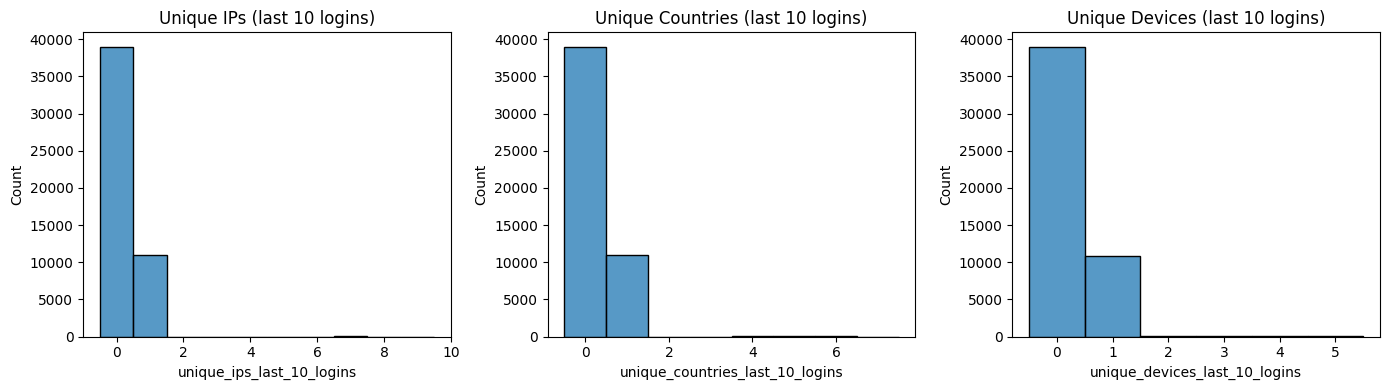

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ["unique_ips_last_10_logins", "unique_countries_last_10_logins", "unique_devices_last_10_logins"],
    ["Unique IPs (last 10 logins)", "Unique Countries (last 10 logins)", "Unique Devices (last 10 logins)"]):
    sns.histplot(df[col], ax=ax, discrete=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [76]:
# compare by anomaly type - average of each feature per anomaly type
login_cols = ["unique_ips_last_10_logins", "unique_countries_last_10_logins", "unique_devices_last_10_logins"]
print(df.groupby("anomaly_type")[login_cols].mean().round(2).sort_values("unique_countries_last_10_logins", ascending=False))

                           unique_ips_last_10_logins  \
anomaly_type                                           
ip_hopper                                       1.06   
brute_forcer                                    0.60   
device_switcher                                 0.24   
dormant_withdrawer                              0.23   
wash_trader                                     0.23   
none                                            0.22   
bot_trader                                      0.22   
kyc_manipulator                                 0.21   
structurer                                      0.19   
consistent_winner                               0.18   
deposit_withdrawal_cycler                       0.16   

                           unique_countries_last_10_logins  \
anomaly_type                                                 
ip_hopper                                             0.90   
brute_forcer                                          0.52   
device_switcher        

### Observations

- Most records have low values for unique IPs, countries, and devices, indicating that users usually log in from familiar locations and devices.
- A small number of records have much higher values, suggesting unusual login behavior and potential anomalies.
- The `ip_hopper` anomaly type has the highest average number of unique IPs and countries, matching its simulated behavior of frequent location changes.
- `device_switcher` users show relatively higher unique device counts compared to other anomaly types.
- `brute_forcer` users also exhibit elevated unique IP counts, likely due to repeated login attempts from different IP addresses.
- Overall, these login-based features provide good separation between normal users and iphoppers and bruteforcer

## Task 5: Financial Behavior

Analyzing `withdrawal_to_deposit_ratio` and `roll_5_deposit_sum`

In [77]:
# the ratio has extreme outliers so look at it carefully
print("withdrawal_to_deposit_ratio describe:")
print(df["withdrawal_to_deposit_ratio"].describe())
print()
print("roll_5_deposit_sum describe:")
print(df["roll_5_deposit_sum"].describe())

withdrawal_to_deposit_ratio describe:
count    50000.000000
mean         0.017519
std          0.493320
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         76.911143
Name: withdrawal_to_deposit_ratio, dtype: float64

roll_5_deposit_sum describe:
count    50000.000000
mean      1702.112945
std       3659.618278
min       -335.210000
25%          0.000000
50%          0.000000
75%          0.000000
max      44050.100000
Name: roll_5_deposit_sum, dtype: float64


In [78]:
# top users by withdrawal ratio
wd = df[df["withdrawal_to_deposit_ratio"] > 0].copy()
top_wd = wd.nlargest(10, "withdrawal_to_deposit_ratio")[["user_id", "anomaly_type", "withdrawal_to_deposit_ratio", "amount"]]
print("Top 10 by withdrawal_to_deposit_ratio:")
print(top_wd)

Top 10 by withdrawal_to_deposit_ratio:
        user_id        anomaly_type  withdrawal_to_deposit_ratio    amount
1546  USER_0014     kyc_manipulator                    76.911143  39737.68
1548  USER_0014     kyc_manipulator                    52.938258  27351.61
1552  USER_0014     kyc_manipulator                    39.967271  20649.89
1550  USER_0014     kyc_manipulator                    23.966129  12382.58
827   USER_0007     kyc_manipulator                    20.995089  37021.06
825   USER_0007     kyc_manipulator                    18.307057  32281.20
821   USER_0007     kyc_manipulator                    16.735346  29509.77
823   USER_0007     kyc_manipulator                     6.192625  10919.58
2547  USER_0023  dormant_withdrawer                     5.514454  44109.40
2548  USER_0023  dormant_withdrawer                     3.755279  30037.99


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_6460\1710101954.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Normal", "Anomalous"])


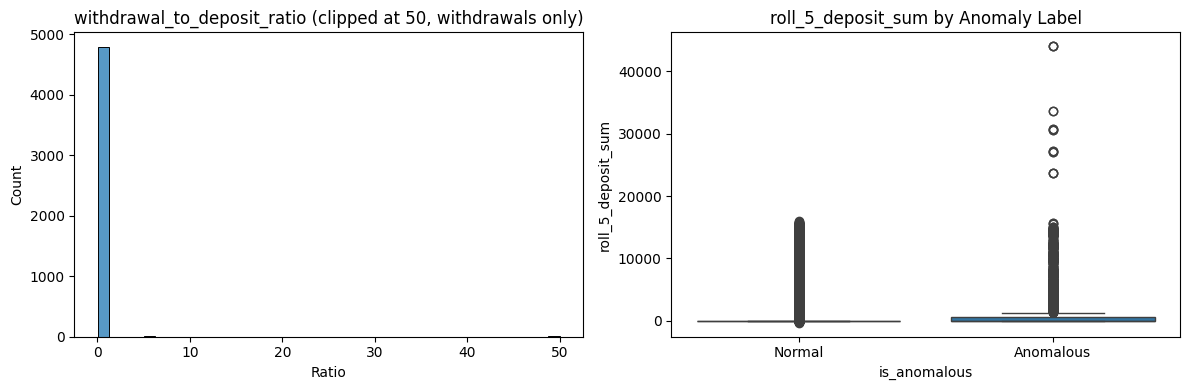

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# clip extreme ratio for plotting
ratio_clipped = df["withdrawal_to_deposit_ratio"].clip(upper=50)
sns.histplot(ratio_clipped[ratio_clipped > 0], bins=40, ax=axes[0])
axes[0].set_title("withdrawal_to_deposit_ratio (clipped at 50, withdrawals only)")
axes[0].set_xlabel("Ratio")

sns.boxplot(data=df, x="is_anomalous", y="roll_5_deposit_sum", ax=axes[1])
axes[1].set_xticklabels(["Normal", "Anomalous"])
axes[1].set_title("roll_5_deposit_sum by Anomaly Label")

plt.tight_layout()
plt.show()

**Observations:**
- kyc_manipulator has the highest ratio (up to 76x) — they withdraw far 
  more than they ever deposited, right after changing their identity details

- dormant_withdrawer has the largest raw withdrawal amounts (up to ₹44,109) 
  even though their ratio is lower, because they had some deposit history

- The histogram shows most ratios cluster near 0 — the high ratio events 
  are rare but clearly associated with specific fraud patterns

- roll_5_deposit_sum is near 0 for 75% of rows since it only has a value 
  on deposit events — anomalous users show higher outliers on the right




## Task 6: Z-Score Analysis

Analyzing `trade_vol_zscore`, `amount_zscore`, `session_duration_zscore`

In [80]:
# how many exceed ±2 and ±3
for col in ["trade_vol_zscore", "amount_zscore", "session_duration_zscore"]:
    gt2 = (df[col].abs() > 2).sum()
    gt3 = (df[col].abs() > 3).sum()
    print(f"{col}:")
    print(f"  |z| > 2 : {gt2} events")
    print(f"  |z| > 3 : {gt3} events")
    print()

trade_vol_zscore:
  |z| > 2 : 738 events
  |z| > 3 : 28 events

amount_zscore:
  |z| > 2 : 401 events
  |z| > 3 : 17 events

session_duration_zscore:
  |z| > 2 : 41 events
  |z| > 3 : 0 events



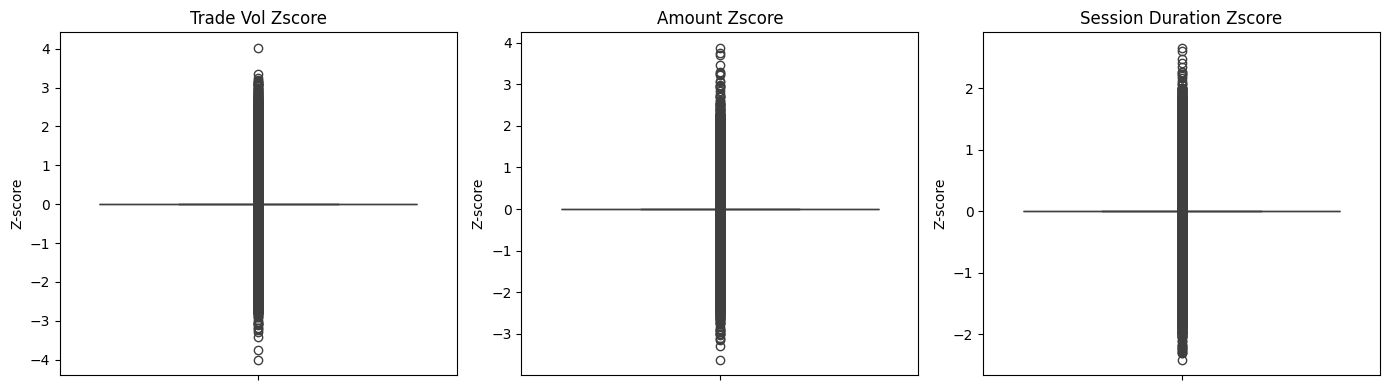

In [88]:
zscore_cols = [
    "trade_vol_zscore",
    "amount_zscore",
    "session_duration_zscore"
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, zscore_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Z-score")

plt.tight_layout()
plt.show()

In [101]:
zscore_cols = [
    "trade_vol_zscore",
    "amount_zscore",
    "session_duration_zscore"
]

for col in zscore_cols:
    print(f"\n{col}")
    print("|z| > 2:", (df[col].abs() > 2).sum())
    print("|z| > 3:", (df[col].abs() > 3).sum())

    print(df[df[col].abs() > 2][
        ["user_id", "anomaly_type", col]
    ].head(10))


trade_vol_zscore
|z| > 2: 738
|z| > 3: 28
       user_id     anomaly_type  trade_vol_zscore
64   USER_0000      wash_trader          2.065063
67   USER_0000      wash_trader          2.260591
69   USER_0000      wash_trader          2.454687
73   USER_0000      wash_trader          2.471530
144  USER_0001      wash_trader          2.027143
145  USER_0001      wash_trader          2.174864
146  USER_0001      wash_trader          2.265370
147  USER_0001      wash_trader          2.106067
152  USER_0001      wash_trader          2.185029
309  USER_0002  device_switcher          2.427611

amount_zscore
|z| > 2: 401
|z| > 3: 17
       user_id               anomaly_type  amount_zscore
73   USER_0000                wash_trader      -2.745302
188  USER_0001                wash_trader      -2.054607
298  USER_0002            device_switcher       2.081557
382  USER_0003  deposit_withdrawal_cycler       2.475857
383  USER_0003  deposit_withdrawal_cycler       2.268469
389  USER_0003  deposit_w

### Observations

* `trade_vol_zscore` has the highest number of extreme values (738 observations with |z| > 2), mainly associated with **wash_trader** anomalies, which intentionally generate unusually large trade volumes.
* `amount_zscore` identifies extreme financial transactions, with **deposit_withdrawal_cycler** and **kyc_manipulator** contributing several observations beyond ±2 and ±3.
* `session_duration_zscore` contains relatively few extreme values (41 observations) and no observations beyond ±3, indicating that session durations are generally less variable than financial activities.
* While most extreme trade volume and amount z-scores are linked to anomaly types, a few normal users (`anomaly_type = none`) also exhibit high z-scores due to natural statistical variation.
* Overall, trade volume and transaction amount are stronger indicators of anomalous behavior than session duration in this dataset.


## Task 7: Correlation Analysis

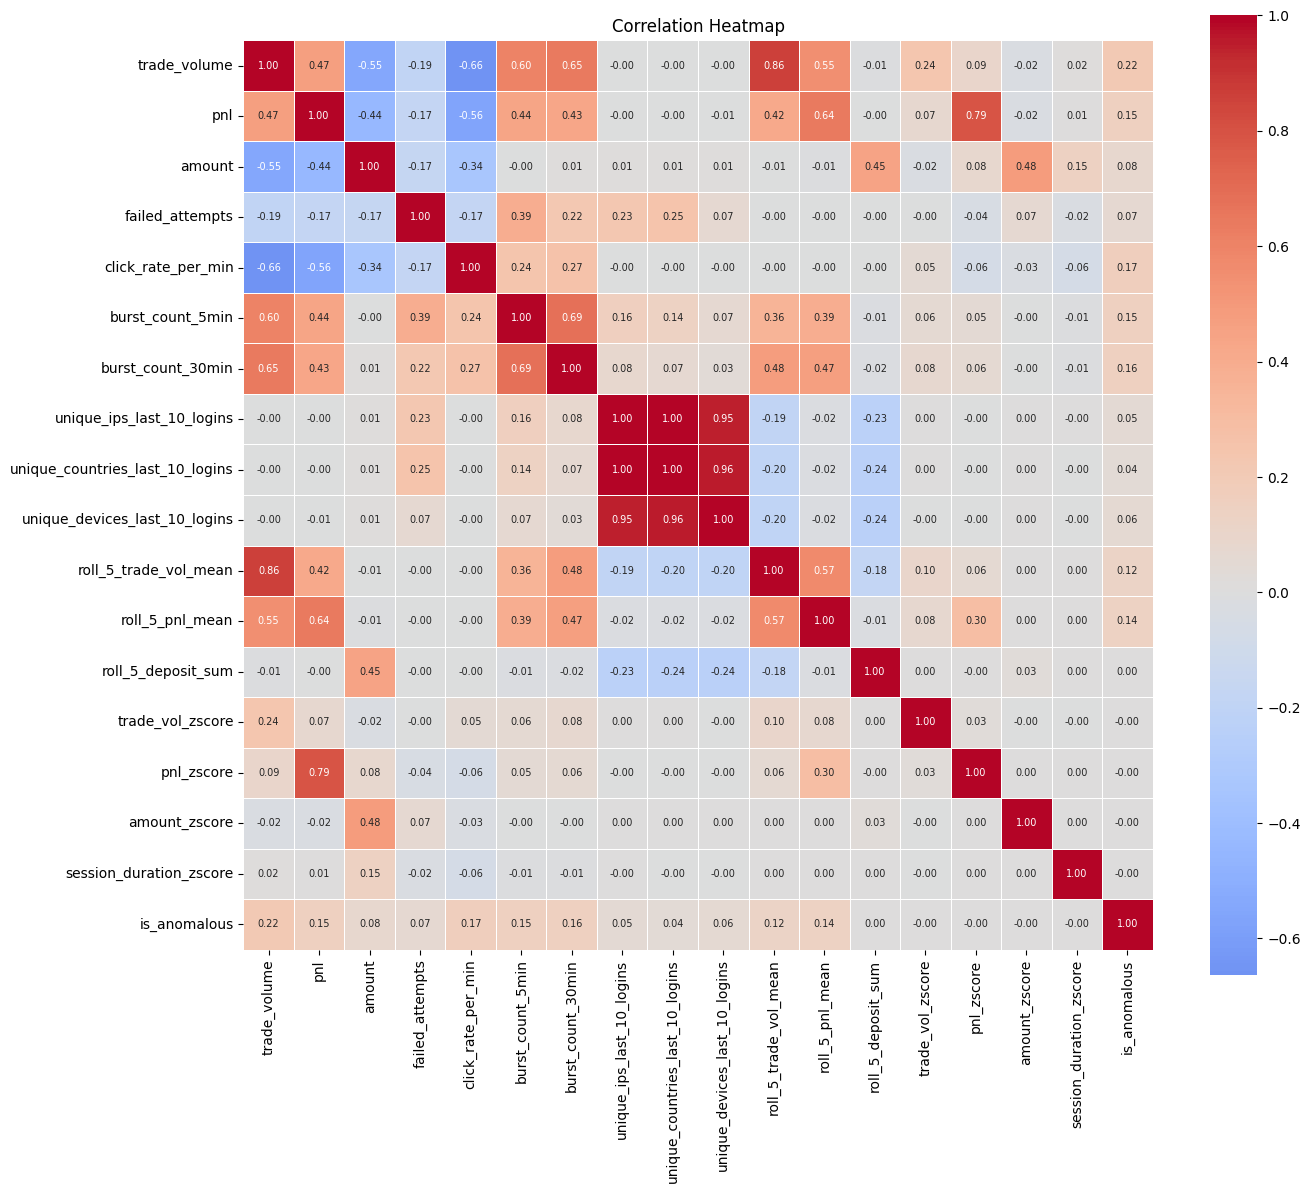

In [102]:
numeric_cols = [
    "trade_volume", "pnl", "amount", "failed_attempts", "click_rate_per_min",
    "burst_count_5min", "burst_count_30min",
    "unique_ips_last_10_logins", "unique_countries_last_10_logins", "unique_devices_last_10_logins",
    "roll_5_trade_vol_mean", "roll_5_pnl_mean", "roll_5_deposit_sum",
    "trade_vol_zscore", "pnl_zscore", "amount_zscore", "session_duration_zscore",
    "is_anomalous"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [103]:
# which features correlate most with is_anomalous
print("Correlation with is_anomalous (sorted):")
print(corr["is_anomalous"].drop("is_anomalous").abs().sort_values(ascending=False))

Correlation with is_anomalous (sorted):
trade_volume                       2.196021e-01
click_rate_per_min                 1.671265e-01
burst_count_30min                  1.554900e-01
pnl                                1.547856e-01
burst_count_5min                   1.527474e-01
roll_5_pnl_mean                    1.394588e-01
roll_5_trade_vol_mean              1.225444e-01
amount                             8.010696e-02
failed_attempts                    6.978020e-02
unique_devices_last_10_logins      6.120433e-02
unique_ips_last_10_logins          5.193764e-02
unique_countries_last_10_logins    4.315014e-02
roll_5_deposit_sum                 3.474973e-03
trade_vol_zscore                   8.858331e-18
session_duration_zscore            2.223497e-18
amount_zscore                      1.456058e-18
pnl_zscore                         4.549002e-19
Name: is_anomalous, dtype: float64


### Observations

* `trade_volume` has the strongest correlation with `is_anomalous` (≈0.22), making it one of the most informative features for detecting anomalous behavior.
* `click_rate_per_min`, `burst_count_5min`, `burst_count_30min`, and `pnl` also show moderate positive correlations with anomalies, suggesting that abnormal trading activity often occurs alongside increased user activity.
* The login-based features (`unique_ips_last_10_logins`, `unique_countries_last_10_logins`, and `unique_devices_last_10_logins`) are highly correlated with each other (≈0.95–1.00), indicating that they capture similar login behavior.
* `roll_5_trade_vol_mean` is strongly correlated with `trade_volume` (≈0.86), while `roll_5_pnl_mean` is moderately correlated with `pnl` (≈0.64), which is expected since these are rolling statistics derived from the original features.
* The z-score features show very low correlation with `is_anomalous` individually, suggesting they are more useful for identifying individual outliers than for explaining anomaly labels on their own.


## Challenge Task: Behavioral Profiles

Picking 3 users - USER_0000 (wash_trader), USER_0002 (device_switcher), USER_0025 (normal)

In [104]:
users = ["USER_0000", "USER_0002", "USER_0025"]

for uid in users:
    u = df[df["user_id"] == uid]
    print(f"{'='*50}")
    print(f"User: {uid}")
    print(f"Anomaly type: {u['anomaly_type'].iloc[0]}")
    print(f"Total events: {len(u)}")
    print(f"Event breakdown: {u['event_type'].value_counts().to_dict()}")
    print(f"Avg trade volume: {u['trade_volume'].mean():.1f}")
    print(f"Avg PnL: {u['pnl'].mean():.1f}")
    print(f"Max burst_count_5min: {u['burst_count_5min'].max()}")
    print(f"Max unique_countries: {u['unique_countries_last_10_logins'].max()}")
    print(f"Max unique_devices: {u['unique_devices_last_10_logins'].max()}")
    print(f"Max failed_attempts: {u['failed_attempts'].max()}")
    print(f"Max trade_vol_zscore: {u['trade_vol_zscore'].max():.2f}")
    print()

User: USER_0000
Anomaly type: wash_trader
Total events: 98
Event breakdown: {'trade': 40, 'login': 22, 'deposit': 14, 'session': 13, 'withdrawal': 5, 'kyc_change': 4}
Avg trade volume: 51729.0
Avg PnL: 860.8
Max burst_count_5min: 3
Max unique_countries: 1.0
Max unique_devices: 1.0
Max failed_attempts: 0.0
Max trade_vol_zscore: 2.47

User: USER_0002
Anomaly type: device_switcher
Total events: 107
Event breakdown: {'trade': 34, 'login': 28, 'deposit': 16, 'session': 13, 'kyc_change': 9, 'withdrawal': 7}
Avg trade volume: 5404.3
Avg PnL: -42.3
Max burst_count_5min: 1
Max unique_countries: 1.0
Max unique_devices: 5.0
Max failed_attempts: 1.0
Max trade_vol_zscore: 2.43

User: USER_0025
Anomaly type: none
Total events: 98
Event breakdown: {'trade': 32, 'login': 24, 'deposit': 18, 'session': 8, 'withdrawal': 8, 'kyc_change': 8}
Avg trade volume: 27612.0
Avg PnL: -20.8
Max burst_count_5min: 2
Max unique_countries: 1.0
Max unique_devices: 1.0
Max failed_attempts: 1.0
Max trade_vol_zscore: 2.22


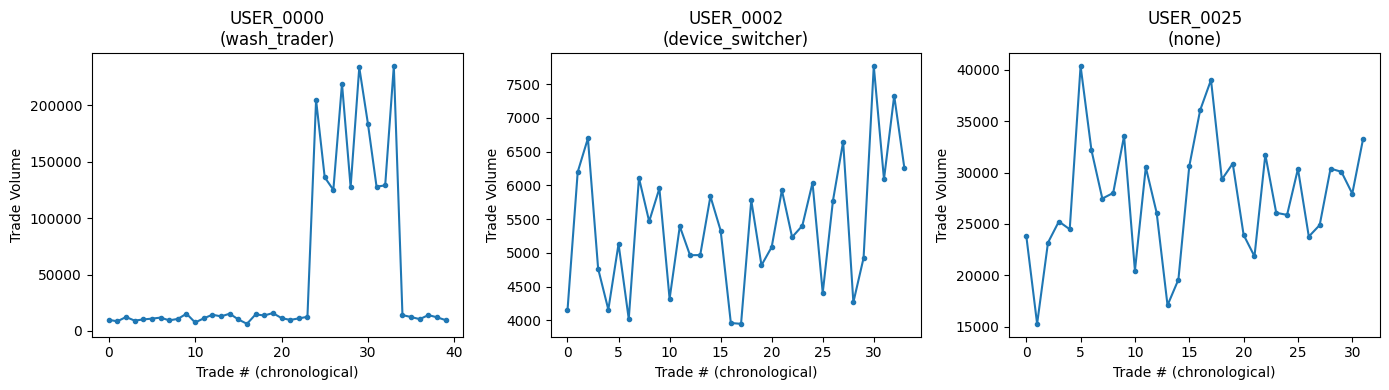

In [105]:
# visualize their trade volumes side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, uid in zip(axes, users):
    u = df[(df["user_id"] == uid) & (df["event_type"] == "trade")]
    label = df[df["user_id"]==uid]["anomaly_type"].iloc[0]
    ax.plot(range(len(u)), u["trade_volume"].values, marker="o", markersize=3)
    ax.set_title(f"{uid}\n({label})")
    ax.set_xlabel("Trade # (chronological)")
    ax.set_ylabel("Trade Volume")

plt.tight_layout()
plt.show()

### USER_0000 – Wash Trader

* Executed the highest average trade volume (**51,729**), with a clear spike in trading activity visible in the timeline.
* Maintained a consistently positive average PnL (**860.8**), which is unusual compared to typical users.
* Login behavior appears normal (single country, single device, no failed login attempts).
* A maximum trade volume z-score of **2.47** indicates several trades that significantly deviate from the user's usual behavior.
* **Conclusion:** This user would likely be flagged due to abnormally high trade volumes and consistently profitable trading, which are characteristic of a wash trading pattern.

### USER_0002 – Device Switcher

* Trading activity and average PnL are within a normal range.
* Logged in from **5 different devices** within the last 10 logins, while remaining in the same country.
* Burst activity and failed login attempts are low, suggesting that the anomaly is primarily related to device usage.
* **Conclusion:** This user would likely be flagged based on unusual device-switching behavior rather than financial activity.

### USER_0025 – Normal User

* Shows stable trading activity with an average trade volume of **27,612** and a slightly negative average PnL (**−20.8**).
* Login behavior is consistent, with only one country and one device used.
* Burst activity is low and no unusual behavioral patterns are observed.
* Although one trade reached a z-score above 2, it appears to be an isolated statistical outlier rather than a persistent pattern.
* **Conclusion:** This user exhibits typical platform behavior and would be unlikely to be classified as anomalous.

